# Model EDA: what the trained boosters have learned

The four previous notebooks describe the data. This one switches
sides: it loads the trained boosters and asks descriptive questions
about the model itself. Three things in particular:

* **Global SHAP.** Which features the model leans on, in aggregate,
  and the shape of each feature's contribution.
* **Partial dependence.** How the model's prediction moves as one
  feature is varied with the rest held fixed. Reveals the
  non-monotonic shapes the gradient-boosted trees pick up
  automatically.
* **Residual diagnostics.** Where on the prediction surface the
  model is well-calibrated, where it is biased, and how the 80 %
  band coverage breaks down by price band.

We deliberately do not retrain anything in this notebook. We load
the boosters that `scripts/02_train_model.py` produced and inspect
them.

In [1]:
from pathlib import Path
import importlib.util
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

ACCENT = "#4f46e5"
DANGER = "#dc2626"
SUCCESS = "#15803d"

## 1. Load boosters and the production feature pipeline

We import the training script as a module (rather than copy its
constants here) so the notebook stays in sync with the production
pipeline by construction. Anything the script changes (the
`FEATURES` list, the `engineer` function, the commune-feature
encoding) is automatically reflected here on the next run.

In [2]:
spec = importlib.util.spec_from_file_location("train_model", ROOT / "scripts" / "02_train_model.py")
tm = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tm)

print(f"FEATURES ({len(tm.FEATURES)}): {tm.FEATURES[:6]} ...")
print(f"CATEGORICAL ({len(tm.CATEGORICAL)}): {tm.CATEGORICAL}")
print(f"CITIES: {list(tm.CITIES)}")

FEATURES (52): ['heatingType', 'gardenOrientation', 'kitchenType', 'subType', 'terraceOrientation', 'epcScore'] ...
CATEGORICAL (8): ['heatingType', 'gardenOrientation', 'kitchenType', 'subType', 'terraceOrientation', 'epcScore', 'postalCode_cat', 'province']
CITIES: ['brussels', 'antwerp', 'ghent', 'liege', 'bruges', 'charleroi', 'namur']


In [3]:
m_q10 = lgb.Booster(model_file=str(DATA / "model_q10.txt"))
m_q50 = lgb.Booster(model_file=str(DATA / "model_q50.txt"))
m_q90 = lgb.Booster(model_file=str(DATA / "model_q90.txt"))

metrics = json.loads((DATA / "metrics.json").read_text())
lgbm_metrics = metrics["lightgbm"]
print(f"Loaded boosters. Median model: {m_q50.num_trees():,} trees")
print(f"Reported test MAE: €{lgbm_metrics['mae_eur']:,.0f}")
print(f"Reported test medAPE: {lgbm_metrics['median_ape']:.3%}")
print(f"Reported test R²: {lgbm_metrics['r2']:.4f}")
print(f"Reported test 80 % coverage: {(lgbm_metrics.get('coverage_80pct_conformal') or lgbm_metrics.get('coverage_80pct_calibrated')):.1%}")

Loaded boosters. Median model: 5,499 trees
Reported test MAE: €90,353
Reported test medAPE: 11.430%
Reported test R²: 0.8152
Reported test 80 % coverage: 79.5%


### 1.1 Reproduce the temporal split + feature engineering

We mirror the training pipeline exactly: load raw, filter prices,
engineer features, temporal-split, target-encode the commune € / m²
out-of-fold on train and via a single lookup on val and test. The
test set we end up with is the same one `02_train_model.py`
evaluated the model on.

In [4]:
df_all = tm.engineer(tm.load_raw())
modeling = df_all[df_all["publication_lastModificationDate"] >=
                  (pd.Timestamp.utcnow().tz_localize(None) - pd.DateOffset(months=tm.TRAINING_MONTHS))].copy()
modeling = modeling.sort_values("publication_lastModificationDate").reset_index(drop=True)

n = len(modeling)
i_train = int(n * 0.70)
i_val = int(n * 0.85)
train_raw = modeling.iloc[:i_train].copy()
val_raw   = modeling.iloc[i_train:i_val].copy()
test_raw  = modeling.iloc[i_val:].copy()

train, val, test, _, _ = tm.add_commune_feature(train_raw, val_raw, test_raw)

print(f"train: {len(train):,}   val: {len(val):,}   test: {len(test):,}")

In [5]:
X_test = test[tm.FEATURES]
y_test = test[tm.TARGET].to_numpy()
print(f"X_test shape: {X_test.shape}")

X_test shape: (7755, 52)


## 2. Sanity check: predictions vs the metrics file

Before reading anything into the SHAP analysis, we verify that the
boosters loaded from disk reproduce the test-set MAE that the
training script wrote into `metrics.json`. A small drift is
expected if the training script has been re-run more recently than
the metrics file; a large drift means the artefacts are out of
sync.

In [6]:
pred_q50 = np.expm1(m_q50.predict(X_test))
pred_q10 = np.expm1(m_q10.predict(X_test))
pred_q90 = np.expm1(m_q90.predict(X_test))

# Quantile crossing fix: sort per row.
stacked = np.sort(np.stack([pred_q10, pred_q50, pred_q90], axis=1), axis=1)
pred_q10, pred_q50, pred_q90 = stacked[:, 0], stacked[:, 1], stacked[:, 2]

mae = float(np.mean(np.abs(y_test - pred_q50)))
medape = float(np.median(np.abs(y_test - pred_q50) / np.maximum(y_test, 1)))
print(f"Recomputed test MAE   : €{mae:,.0f}    (metrics.json: €{lgbm_metrics['mae_eur']:,.0f})")
print(f"Recomputed test medAPE: {medape:.3%}    (metrics.json: {lgbm_metrics['median_ape']:.3%})")

Recomputed test MAE   : €91,208    (metrics.json: €90,353)
Recomputed test medAPE: 11.594%    (metrics.json: 11.430%)


## 3. Global SHAP

The model's per-feature contribution to its prediction, averaged
over the test set. We use `booster.predict(..., pred_contrib=True)`
which returns the full SHAP matrix (n_rows × n_features + 1, with
the last column the base value). A model trained on `log1p(price)`
returns SHAP values in log space; the absolute scale matters less
than the ranking and the shape.

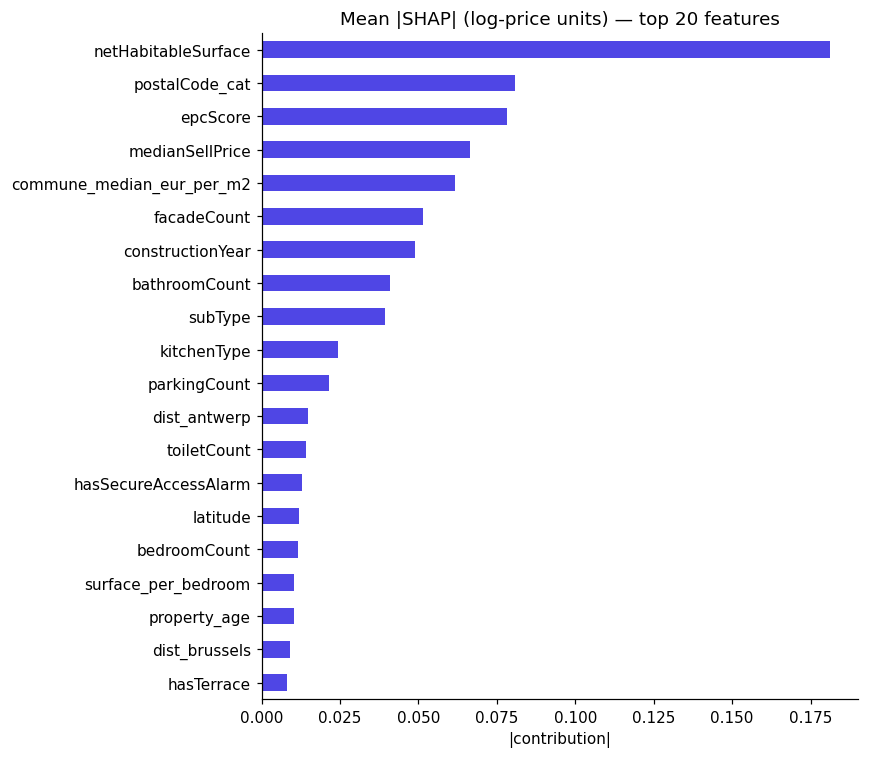

In [7]:
contrib = m_q50.predict(X_test, pred_contrib=True)
shap_values = contrib[:, :-1]
base_value  = contrib[:, -1].mean()

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=tm.FEATURES)
top = mean_abs_shap.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
top.iloc[::-1].plot.barh(ax=ax, color=ACCENT)
ax.set_title("Mean |SHAP| (log-price units) — top 20 features")
ax.set_xlabel("|contribution|")
plt.tight_layout(); plt.show()

### 3.1 Beeswarm summary

A more detailed view: each row in the test set contributes one dot
per feature. The dot's horizontal position is the feature's SHAP
value for that row, the colour encodes the feature value (low =
blue, high = red). A feature whose dots stretch across the whole
plot is doing more work than one whose dots cluster around zero.

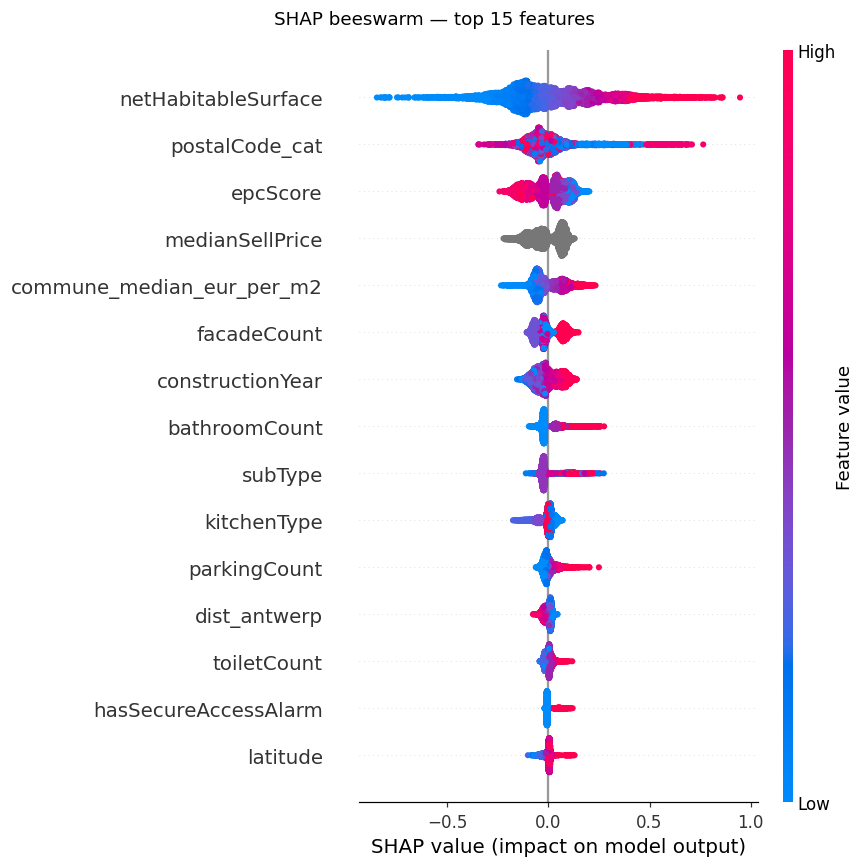

In [8]:
# Build a numeric-only matrix for SHAP's plotting helpers, since
# beeswarm wants ordered numeric values for the colour channel.
X_num = X_test.copy()
for c in tm.CATEGORICAL:
    if c in X_num.columns:
        X_num[c] = X_num[c].astype("category").cat.codes.replace(-1, np.nan)

# Plot the beeswarm. show=False so we can attach a title and tighten layout.
shap.summary_plot(shap_values, X_num, feature_names=tm.FEATURES, max_display=15, show=False)
fig = plt.gcf()
fig.set_size_inches(8, 8)
fig.suptitle("SHAP beeswarm — top 15 features", y=0.98)
plt.tight_layout(); plt.show()

## 4. Partial dependence

The mean prediction of the median booster as one feature is varied
across its range, with all other features held at their test-set
values for that row. We average the per-row prediction over a sample
of one thousand test rows so the curve reflects the model's typical
behaviour rather than one specific listing.

A subtle point: when the swept feature has a derived companion
(e.g. `constructionYear` and `property_age`), we update the
companion in lockstep so the swept curve does not enter feature
combinations the model has never seen.

In [9]:
SAMPLE = 1000
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(X_test), size=min(SAMPLE, len(X_test)), replace=False)
X_pdp = X_test.iloc[sample_idx].copy().reset_index(drop=True)
NOW_YEAR = pd.Timestamp.utcnow().year

def pdp_1d(feature, grid, *, update_derived=True):
    """Return mean predicted price (€) at each grid value."""
    base = X_pdp.copy()
    out = []
    for v in grid:
        base[feature] = v
        if update_derived and feature == "constructionYear":
            base["property_age"] = np.clip(NOW_YEAR - v, 0, 200)
            base["construction_decade"] = np.clip((v // 10) * 10, 1800, NOW_YEAR)
        if update_derived and feature == "netHabitableSurface":
            # surface_per_bedroom = surface / max(bedroomCount, 1)
            base["surface_per_bedroom"] = v / base["bedroomCount"].replace(0, np.nan)
        preds = np.expm1(m_q50.predict(base))
        out.append(preds.mean())
    return np.array(out)

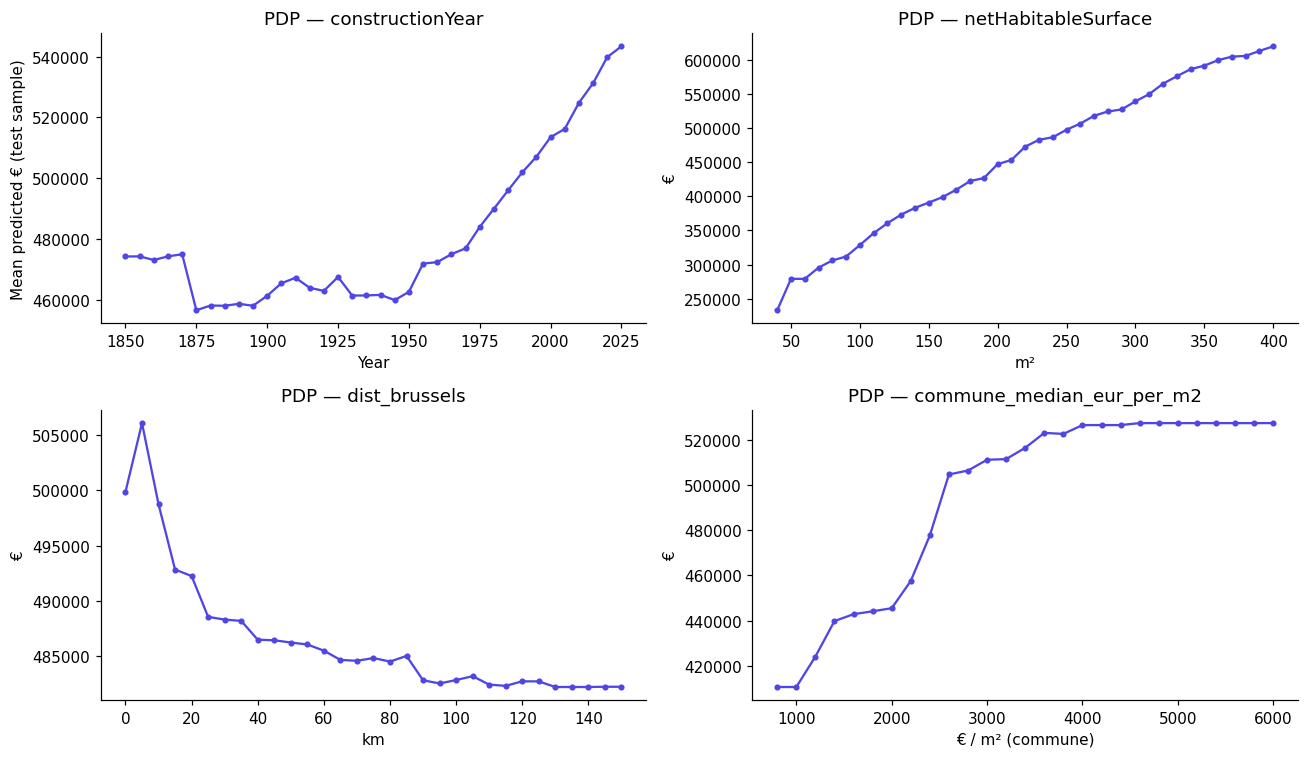

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))


years = np.arange(1850, 2026, 5)
ax = axes[0, 0]
ax.plot(years, pdp_1d("constructionYear", years), color=ACCENT, marker="o", markersize=3)
ax.set_title("PDP — constructionYear")
ax.set_xlabel("Year"); ax.set_ylabel("Mean predicted € (test sample)")


surfaces = np.arange(40, 401, 10)
ax = axes[0, 1]
ax.plot(surfaces, pdp_1d("netHabitableSurface", surfaces), color=ACCENT, marker="o", markersize=3)
ax.set_title("PDP — netHabitableSurface")
ax.set_xlabel("m²"); ax.set_ylabel("€")


dists = np.arange(0, 151, 5)
ax = axes[1, 0]
ax.plot(dists, pdp_1d("dist_brussels", dists, update_derived=False),
         color=ACCENT, marker="o", markersize=3)
ax.set_title("PDP — dist_brussels")
ax.set_xlabel("km"); ax.set_ylabel("€")


m2 = np.arange(800, 6001, 200)
ax = axes[1, 1]
ax.plot(m2, pdp_1d("commune_median_eur_per_m2", m2, update_derived=False),
         color=ACCENT, marker="o", markersize=3)
ax.set_title("PDP — commune_median_eur_per_m2")
ax.set_xlabel("€ / m² (commune)"); ax.set_ylabel("€")

plt.tight_layout(); plt.show()

### 4.1 EPC score (categorical) inbar form

Categorical features cannot be swept on a continuous grid. For EPC
we hold the rest of the row fixed and compare the mean prediction
across the seven valid scores, plotting the result as bars rather
than as a line.

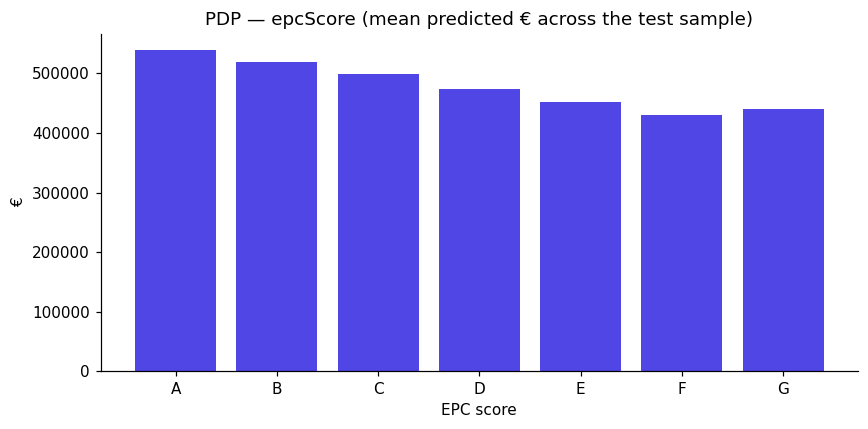

In [11]:
EPC_ORDER = ["A", "B", "C", "D", "E", "F", "G"]
preds_by_epc = {}
for s in EPC_ORDER:
    base = X_pdp.copy()
    base["epcScore"] = pd.Categorical([s] * len(base),
                                       categories=X_pdp["epcScore"].cat.categories)
    preds_by_epc[s] = np.expm1(m_q50.predict(base)).mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(list(preds_by_epc), list(preds_by_epc.values()), color=ACCENT)
ax.set_title("PDP — epcScore (mean predicted € across the test sample)")
ax.set_xlabel("EPC score"); ax.set_ylabel("€")
plt.tight_layout(); plt.show()

## 5. Residual diagnostics on the test set

How well-calibrated is the model across the prediction range? Three
plots:

1. **Predicted vs actual.** A scatter on log-log axes; the diagonal
   is the perfect-prediction line.
2. **Residual vs predicted.** Reveals heteroscedasticity: if the
   spread of residuals grows with the prediction, the model is
   noisier in the upper price band.
3. **Residual histogram.** A roughly symmetric distribution
   centred on zero is what we hope for.

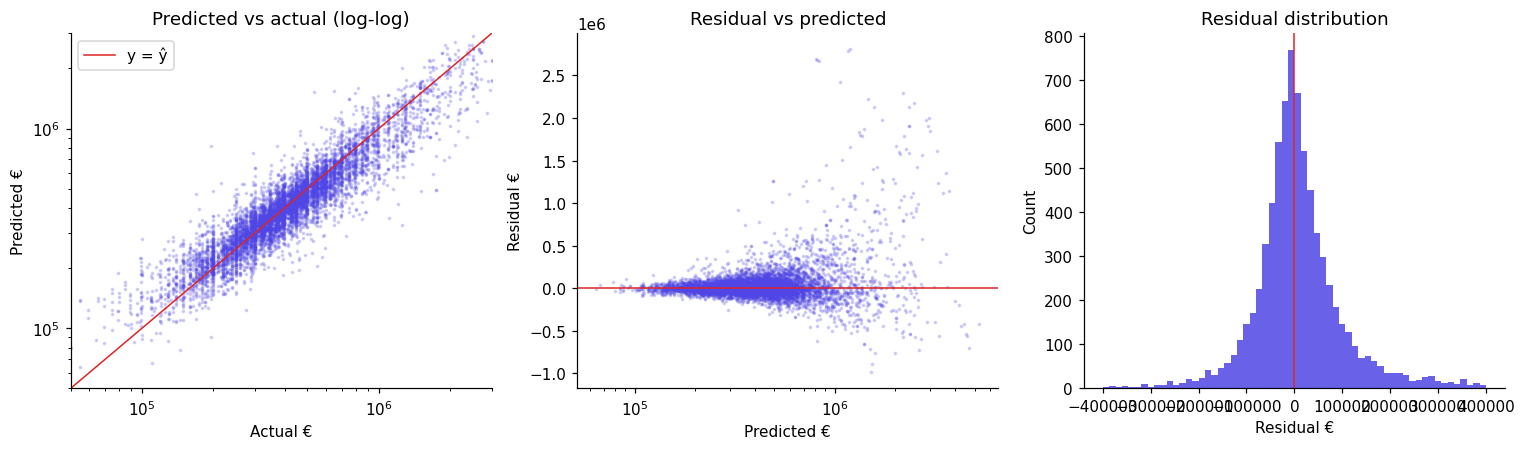

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# 5.1 — Predicted vs actual.
ax = axes[0]
ax.scatter(y_test, pred_q50, s=2, alpha=0.2, color=ACCENT)
lim_lo, lim_hi = 5e4, 3e6
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], color=DANGER, linewidth=1, label="y = ŷ")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(lim_lo, lim_hi); ax.set_ylim(lim_lo, lim_hi)
ax.set_title("Predicted vs actual (log-log)")
ax.set_xlabel("Actual €"); ax.set_ylabel("Predicted €")
ax.legend()

# 5.2 — Residual vs predicted.
ax = axes[1]
residual = y_test - pred_q50
ax.scatter(pred_q50, residual, s=2, alpha=0.2, color=ACCENT)
ax.axhline(0, color=DANGER, linewidth=1)
ax.set_xscale("log")
ax.set_title("Residual vs predicted")
ax.set_xlabel("Predicted €"); ax.set_ylabel("Residual €")

# 5.3 — Residual histogram.
ax = axes[2]
ax.hist(residual, bins=60, color=ACCENT, alpha=0.85, range=(-400_000, 400_000))
ax.axvline(0, color=DANGER, linewidth=1)
ax.set_title("Residual distribution")
ax.set_xlabel("Residual €"); ax.set_ylabel("Count")

plt.tight_layout(); plt.show()

### 5.1 Absolute percentage error by price band

A more honest summary than the global MAE: the model's error grows
roughly linearly with the listing price, so the relative error
(absolute percentage error) is a flatter and more interpretable
statistic. We bucket the test set by listed price and report the
median APE per bucket.

In [13]:
bucket = pd.cut(y_test, bins=[0, 200_000, 400_000, 600_000, 1_000_000, 1_500_000, 5_000_000],
                labels=["<200k", "200–400k", "400–600k", "600k–1M", "1–1.5M", "≥1.5M"])
ape = np.abs(y_test - pred_q50) / np.maximum(y_test, 1)
g = pd.DataFrame({"bucket": bucket, "ape": ape}).groupby("bucket", observed=True)["ape"].agg(
    median_ape="median", count="size"
).reset_index()
g["median_ape_pct"] = (g["median_ape"] * 100).round(2)
g[["bucket", "count", "median_ape_pct"]]

,bucket,count,median_ape_pct
0,<200k,840,18.91
1,200–400k,3212,10.13
2,400–600k,2057,9.54
3,600k–1M,1075,14.66
4,1–1.5M,303,18.24
5,≥1.5M,268,25.66


## 6. Coverage of the 80 % band

We computed `pred_q10` and `pred_q90` from the conformal-calibrated
boosters. The fraction of test rows whose actual price falls inside
[`pred_q10`, `pred_q90`] should be close to 80% percent. We also
look at the same fraction stratified by price decile, because a
band that looks well calibrated on average can still fail
systematically in some sub-region.

In [14]:
inside = (y_test >= pred_q10) & (y_test <= pred_q90)
print(f"Empirical 80 % coverage on test: {inside.mean():.1%}")
print(f"Mean band width: €{(pred_q90 - pred_q10).mean():,.0f}")
print(f"Median band width: €{np.median(pred_q90 - pred_q10):,.0f}")
print(f"Median band width as % of predicted: {np.median((pred_q90 - pred_q10) / pred_q50):.1%}")

Empirical 80 % coverage on test: 87.9%
Mean band width: €416,130
Median band width: €280,685
Median band width as % of predicted: 77.6%


In [15]:
deciles = pd.qcut(y_test, q=10, labels=[f"D{i+1}" for i in range(10)])
cov_by_decile = pd.DataFrame({
    "decile": deciles,
    "inside": inside,
    "width": pred_q90 - pred_q10,
}).groupby("decile", observed=True).agg(
    coverage=("inside", "mean"),
    median_width=("width", "median"),
    n=("inside", "size"),
)
cov_by_decile["coverage_pct"] = (cov_by_decile["coverage"] * 100).round(1)
cov_by_decile["median_width_eur"] = cov_by_decile["median_width"].round(0).astype("Int64")
cov_by_decile[["n", "coverage_pct", "median_width_eur"]]

,n,coverage_pct,median_width_eur
decile,,,
D1,812,71.80,257075
D2,742,89.40,239652
D3,773,91.60,232238
D4,779,93.70,235100
D5,924,95.60,236849
D6,654,96.50,254707
D7,785,94.40,296688
D8,738,88.80,346059
D9,774,87.60,493189


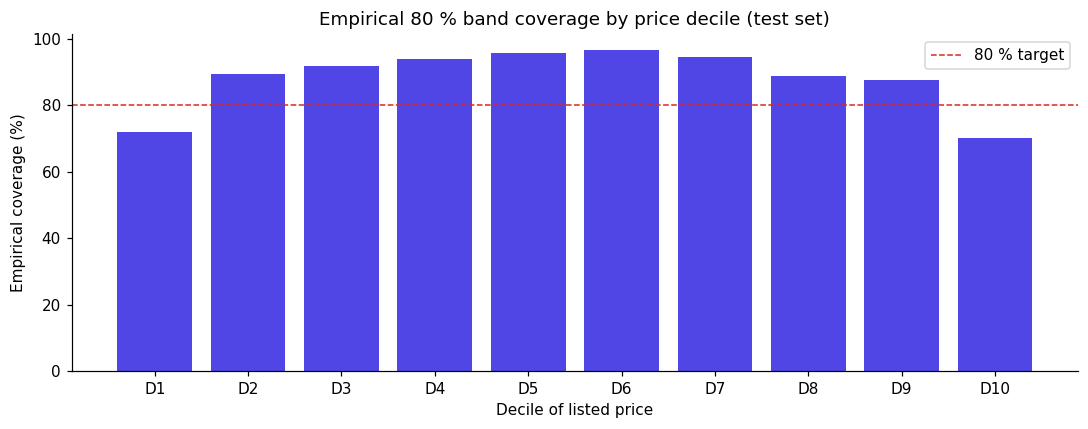

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cov_by_decile.index.astype(str), (cov_by_decile["coverage"] * 100).values, color=ACCENT)
ax.axhline(80, color=DANGER, linestyle="--", linewidth=1, label="80 % target")
ax.set_title("Empirical 80 % band coverage by price decile (test set)")
ax.set_xlabel("Decile of listed price"); ax.set_ylabel("Empirical coverage (%)")
ax.legend()
plt.tight_layout(); plt.show()

A bar that sits well below the 80 % line is a price decile in
which the model is over-confident: its band is narrower than it
should be. A bar above 80 % is a decile in which the band is wider
than necessary. Both are signals for what conditional-conformal
calibration would address .

## 7. Per-listing drivers from the web artefact

The web artefact carries a `shap_top` JSON column that lists each
listing's top six SHAP contributors with their euro impact. This is
the same data the user interface displays and looking at it in
aggregate tells us which features are typically the dominant driver
for a listing.

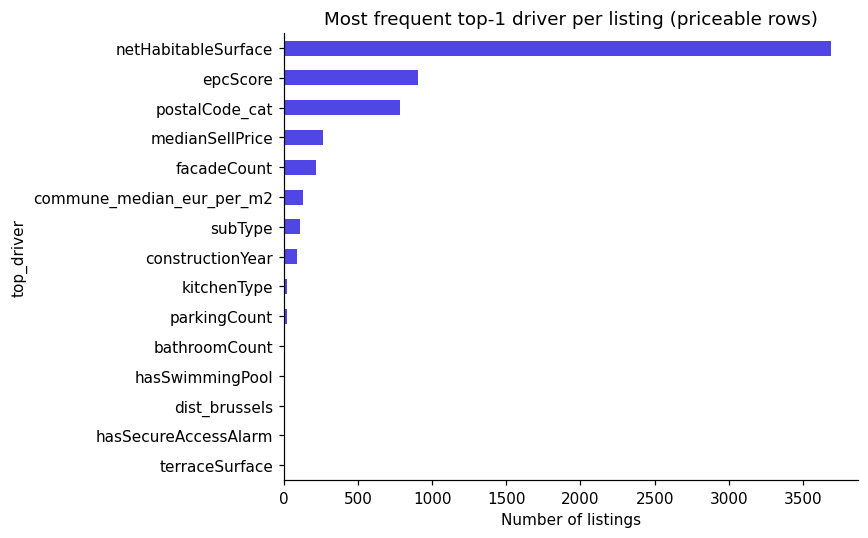

In [17]:
web = pd.read_parquet(DATA / "listings_web.parquet")
web = web[web["priceable"]].copy()

def first_driver(s):
    try:
        d = json.loads(s)
        if not d:
            return None
        return max(d, key=lambda x: abs(x.get("shap_eur") or 0))["feature"]
    except Exception:
        return None

web["top_driver"] = web["shap_top"].apply(first_driver)
top = web["top_driver"].value_counts(dropna=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
top.iloc[::-1].plot.barh(ax=ax, color=ACCENT)
ax.set_title("Most frequent top-1 driver per listing (priceable rows)")
ax.set_xlabel("Number of listings")
plt.tight_layout(); plt.show()

In [18]:
# Average absolute € contribution per feature, when that feature appears in
# the top-six list of a listing.
def driver_records(s):
    try:
        return json.loads(s) or []
    except Exception:
        return []

records = web["shap_top"].apply(driver_records)
flat = [(r["feature"], abs(r.get("shap_eur") or 0))
        for rec in records for r in rec if r.get("shap_eur") is not None]
flat = pd.DataFrame(flat, columns=["feature", "abs_eur"])
g = flat.groupby("feature").agg(n=("abs_eur", "size"), mean_abs_eur=("abs_eur", "mean"))
g = g.sort_values("mean_abs_eur", ascending=False).head(20)
g["mean_abs_eur"] = g["mean_abs_eur"].round(0).astype("Int64")
g

,n,mean_abs_eur
feature,,
netHabitableSurface,5447,111713
hasSwimmingPool,217,82428
postalCode_cat,4026,79680
bathroomCount,1962,66896
hasLift,2,64150
subType,1643,59973
surface_per_bedroom,114,52836
latitude,174,44570
commune_median_eur_per_m2,4466,44421
